# Pre-processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, randint
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
#%pip install xgboost
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import RandomizedSearchCV,cross_val_predict
import matplotlib.patches as mpatches


In [2]:
df = pd.read_csv("0131_2.csv")
df2 = pd.read_csv("0131_3.csv")
df3 = pd.read_csv("0206_1.csv")
#df = pd.concat([df,df2], axis=0)
#df = pd.concat([df, df3], axis =0)
#for i in range(2,16):
#    partialDF = pd.read_csv(f"{i}.csv", header=None)
#    df = pd.concat([df,partialDF],ignore_index=True, axis=0)
#df
dfList=[df,df2,df3]

In [3]:
for item in dfList: #for each CSV
    j=1
    while(j<=2):#for each class in that CSV
        bike1 = df[df["Class"]== j] #sort by Class, seperate into 1 and 0 data frames
        bike1 = bike1.drop(columns = "Class")
        condensedDf = pd.DataFrame(columns=[])
        columns=['MagX1', 'MagY1', 'MagZ1', 'AccX1', 'AccY1', 'AccZ1', 'MagX2', 'MagY2', 'MagZ2']

        i = 0
        for columnName in bike1:
            name = columns[i]
            #find min, max, average and stdev for each column
            mean = bike1[columnName].mean()
            minVal = bike1[columnName].min()
            maxVal = bike1[columnName].max()
            stdVal = bike1[columnName].std()
            newColumn = [mean, stdVal, minVal, maxVal]#make a list
            condensedDf.insert(i,name, newColumn)#add each column to the new data frame
            i+=1

        cols_to_drop = condensedDf.columns[condensedDf.isnull().any()].tolist()# Identify columns with any NaN values
        condensedDf = condensedDf.drop(cols_to_drop, axis=1) # Drop the identified columns
        
        
        
        numpyData = condensedDf.to_numpy().flatten() #convert to numpy & flatten to one column
        numpyData = np.append(numpyData, j) #append class = j to the end of the numpy array
        
        finalDf = numpyData.reshape(1, -1) #reshape numpy to be a single row rather than a column
        
        finalDf = pd.DataFrame(finalDf) #reconvert to pandas df to allow for csv writing
        finalDf.to_csv('processedData.csv', header=None, index = False, mode = "a")
        j+=1
print("Processed data output successfully to processedData.csv")

Processed data output successfully to processedData.csv


# Machine Learning Algorithm Experimentation

In [4]:
#https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/
#The general setup for the model is here
df = pd.read_csv('processedData.csv', header=None)

y = df[36].to_numpy() # gets list of classes
df.drop(36, axis=1, inplace=True) # remove classes from data

X = df[df.columns].to_numpy() # convert remaining data to numpy array
#X = StandardScaler().fit_transform(X) #run standard scalar to normalize data
#normalizing -> data needs to be quantized into a short -> ignore for now

train_size = 0.8
test_size = 1-train_size
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, test_size = test_size, random_state=42)
print("test\\train splitting complete")
print(f"Training: {len(X_train)}, Testing: {len(X_test)}")
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)
y = le.fit_transform(y)

test\train splitting complete
Training: 9, Testing: 3


In [69]:
#Visualization
colorMap = {1: 'red', 2: 'blue', 0: 'black'}
colors = [colorMap[label] for label in df['Class']]
scatter_matrix = pd.plotting.scatter_matrix(df, color=colors)
for ax in scatter_matrix.flatten():
    ax.set_xticks([])
    ax.set_xlabel(ax.get_xlabel(), rotation=45)
    ax.set_ylabel(ax.get_ylabel(), rotation=45)
    ax.set_yticks([])
    
legend_handles = [mpatches.Patch(color=colorMap[1], label='E-Bike'),
                  mpatches.Patch(color=colorMap[2], label='Bike'),
                  mpatches.Patch(color=colorMap[0], label='Neither')]
plt.legend(handles=legend_handles)

plt.suptitle("Sensor Data Scatter Matrix")
#plt.legend(["Bike", "Ebike", "Neither"], loc="upper right")
plt.show()

NameError: name 'colors' is not defined

In [5]:
randomForestClassifier = RandomForestClassifier(n_estimators = 150, criterion="gini", max_features="sqrt", random_state=42)
#Best params from GridSearch: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'sampling_method': 'uniform', 'subsample': 0.5}
#Best params from RandomSearch: {'colsample_bytree': 0.8374758671474549, 'gamma': 0.27280839465796747, 'learning_rate': 0.29243944263295757, 'max_depth': 4, 'n_estimators': 114, 'subsample': 0.9767143382943485}
#xgb_clf = xgb.XGBClassifier(n_estimators=114, learning_rate=0.29243944263295757, max_depth=4, random_state=42, gamma=0.27280839465796747, colsample_bytree=0.8374758671474549, subsample= 0.9767143382943485)
xgb_clf = xgb.XGBClassifier(colsample_bytree= 0.8123620356542087, gamma= 0.4753571532049581, learning_rate= 0.22959818254342154, max_depth= 6, n_estimators= 70, subsample= 0.4936111842654619)
print("Fitting models")
randomForestClassifier.fit(X, y)
xgb_clf.fit(X, y)
print("Model fitting complete")


Fitting models
Model fitting complete


In [6]:
#APR Reference: https://stackoverflow.com/questions/31421413/how-to-compute-precision-recall-accuracy-and-f1-score-for-the-multiclass-case
print("Predicting Model")
y_pred_rf = cross_val_predict(randomForestClassifier,X,y,cv=3)
y_pred_xgb =cross_val_predict(xgb_clf,X,y,cv=3)
print("Complete")

Predicting Model
Complete


In [75]:
print("Accuracy RF:", accuracy_score(y, y_pred_rf))
print("F1 Score RF:", f1_score(y, y_pred_rf, average="macro"))
print("Precision RF:", precision_score(y, y_pred_rf, average="macro"))
print("Recall RF:", recall_score(y, y_pred_rf, average="macro"))
print()
print("Accuracy XGB:", accuracy_score(y, y_pred_xgb))
print("F1 Score XGB:", f1_score(y, y_pred_xgb, average="macro"))
print("Precision XGB:", precision_score(y, y_pred_xgb, average="macro"))
print("Recall XGB:", recall_score(y, y_pred_xgb, average="macro"))

Accuracy RF: 1.0
F1 Score RF: 1.0
Precision RF: 1.0
Recall RF: 1.0

Accuracy XGB: 0.5
F1 Score XGB: 0.3333333333333333
Precision XGB: 0.25
Recall XGB: 0.5


C:\Users\13038\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [7]:
#Sources: https://stackoverflow.com/questions/53782169/random-forest-tuning-with-randomizedsearchcv
# https://medium.com/@thommaskevin/tinyml-xgboost-classifier-795202285779
params = {
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma": uniform(0, 0.5),
    "learning_rate": uniform(0.01, 0.3), 
    "max_depth": randint(2, 10), 
    "n_estimators": randint(50, 250),
    "subsample": uniform(0.4,0.6)#,
    #"reg_lambda": randint(0,10),
    #"reg_alpha": randint(0,10)
}

random_search = RandomizedSearchCV(estimator=xgb_clf, param_distributions=params, cv=3, scoring='accuracy', verbose=1, n_iter = 100, random_state=42)
random_search.fit(X, y)
print("Best parameters found: ", random_search.best_params_)
print("Best score: ", random_search.best_score_)
grid_search_score = random_search.best_estimator_.score(X, y)

print("Test score: ", grid_search_score)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best parameters found:  {'colsample_bytree': 0.7467983561008608, 'gamma': 0.02904180608409973, 'learning_rate': 0.26985284373248053, 'max_depth': 5, 'n_estimators': 153, 'subsample': 0.8248435466776274}
Best score:  1.0
Test score:  1.0


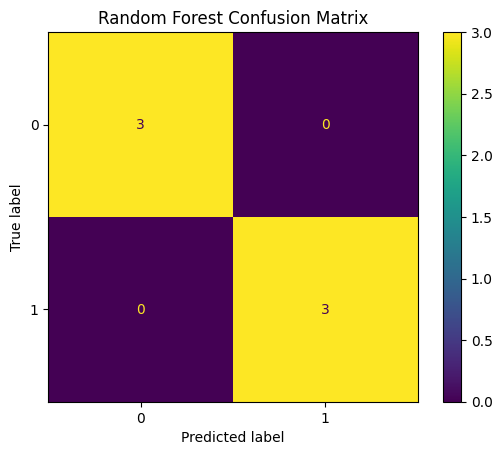

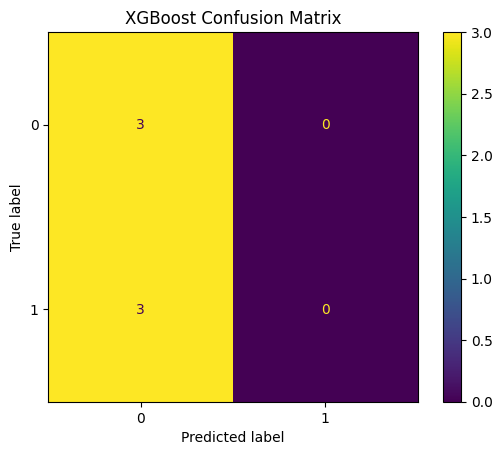

In [80]:
confision_matrix = confusion_matrix(y, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=confision_matrix)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

confision_matrix = confusion_matrix(y, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=confision_matrix)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()